# Part II: Building a market-wide stock screener

The previous notebook trained a four-parameter univariate MMAR on 256-day windows. Here we reuse that saved estimator to analyze every eligible S&P 500 listing in parallel. 

The new additions are a simulation-gap diagnostic, a posterior-predictive gain-versus-tail-loss ranking, and fit checks for the leaders. Independent fits cannot represent portfolio diversification or cross-asset dependence; that limitation motivates the next notebook.

In [ ]:
import numpy as np
import pandas as pd

import bayesflow as bf
import keras

from pathlib import Path
from time import perf_counter
from IPython.display import display

from mmar import screener
from mmar import univariate as model
from mmar.screener import viz

In [2]:
MODEL_PATH = Path("checkpoints/univariate/model.keras")
AS_OF = (pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=1)).date()
FIGURES = Path("figures/screener")
FIGURES.mkdir(parents=True, exist_ok=True)
N_STOCKS = 500
RULE = screener.Rule(round_trip_cost=0.002)

## 1. Reuse the trained univariate MMAR

For stock $j$, the model remains

$$r_{j,t}=\mu_j+\bar\sigma_j\sqrt{\theta_{j,t}(q_j)}\,\varepsilon_{j,t},\qquad
\varepsilon_{j,t}=z_{j,t}\sqrt{(\nu_j-2)/U_{j,t}},$$
$$z_{j,t}\overset{\mathrm{iid}}{\sim}N(0,1),\qquad U_{j,t}\overset{\mathrm{iid}}{\sim}\chi^2_{\nu_j},\qquad z_{j,t}\perp U_{j,t}.$$

Thus $z_{j,t}$ remains the Gaussian seed and $\varepsilon_{j,t}$ the final variance-one Student-$t$ innovation. The saved amortizer maps one raw $256\times1$ simple-return window to posterior draws of daily drift $\mu_j$, baseline scale $\bar\sigma_j$, cascade strength $q_j$, and Student-$t$ degrees of freedom $\nu_j$. No new simulator, parameter, or neural estimator is introduced here.

In [3]:
approximator = keras.saving.load_model(MODEL_PATH)

## 2. Build one market-wide batch

Current constituents are aligned to the last 257 SPY trading dates and converted into 256 simple returns. A listing is eligible only when all required prices are finite and positive and all returns are finite and above $-100\%$. If more than 500 qualify, the first 500 are retained alphabetically—not by performance.

The index can contain more than 500 listings because some companies have multiple share classes. An exclusion therefore records incomplete or invalid vendor history, not an illegitimate security. This is a current-membership screen, not a historical point-in-time universe. The audit below reports every listing explicitly.

[Membership data](https://github.com/datasets/s-and-p-500-companies) and adjusted Yahoo Finance prices are cached in `data/screener/`.

In [ ]:
members = screener.load_universe()
prices = screener.load_prices(members, AS_OF)
series, metadata, dates, universe_audit = screener.stock_windows(
    prices, members, AS_OF, n_stocks=N_STOCKS
    
)

print(f"Raw input: {series.shape} = (stocks, time, channel)")
print(f"Membership snapshot: {members.membership_snapshot.iloc[0]}; last close: {dates[-1].date()}")
display(universe_audit.status.value_counts().rename("stocks").to_frame())
universe_audit.to_csv(FIGURES / "universe_audit.csv", index=False)

### Return histories

Each row is one independently analyzed stock and each column is one trading day. Color shows the simple daily return in percent. Every row passes through the same pretrained estimator.

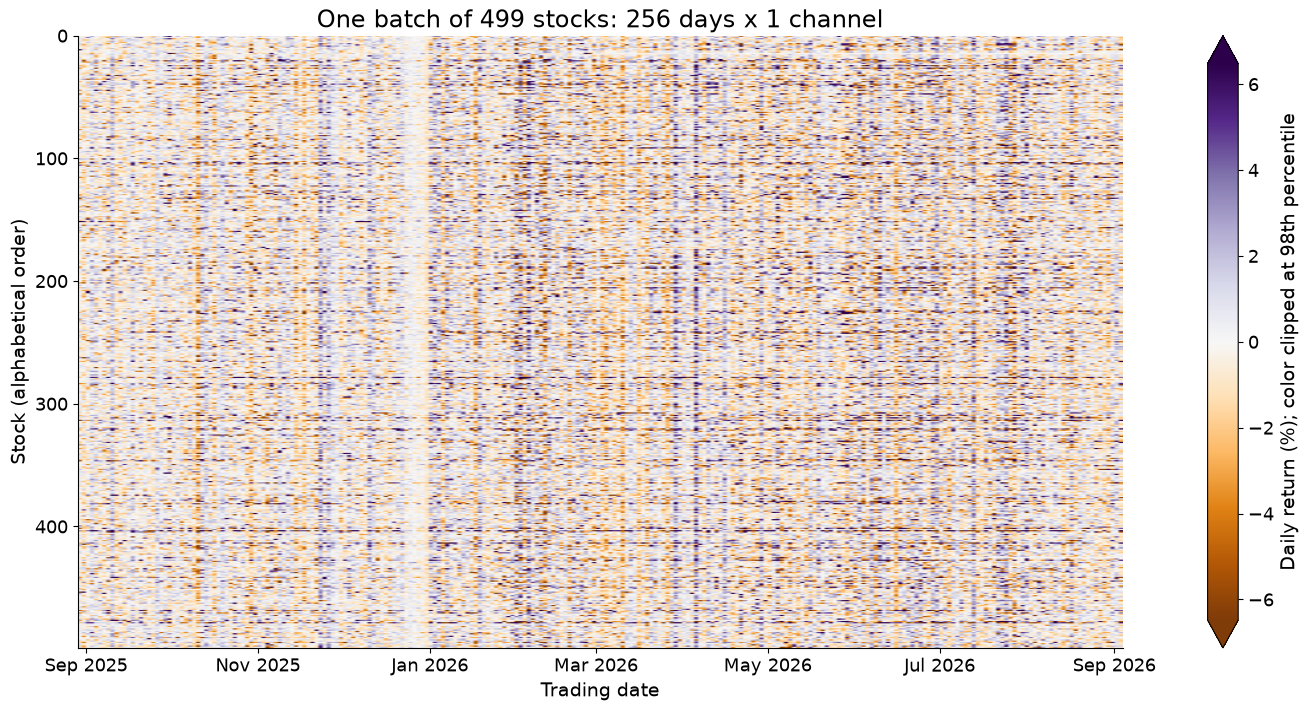

In [5]:
viz.batch_plot(series, dates, FIGURES / "01_stock_batch.png")

## 3. Deploy the amortized artifact

One call processes all $256\times1$ stock windows, internally split into minibatches. For each stock, the network returns posterior draws of the same four parameters and one 16-dimensional learned summary. The timing below covers inference only.

In [12]:
start = perf_counter()
draws = approximator.sample(
    conditions={"returns": series},
    num_samples=512,
    batch_size=100,
    return_summaries=True,
    seed=42,
)
inference_seconds = perf_counter() - start

print(f"{inference_seconds:.2f}s total; {1000 * inference_seconds / len(series):.1f} ms/stock")

Summarizing:   0%|          | 0/5 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/5 [00:00<?, ?batch/s]

0.45s total; 0.9 ms/stock


In [13]:
parameter_draws = {name: draws[name] for name in model.PARAMETER_NAMES}
posterior = model.stack_samples(parameter_draws)
real_summaries = draws["_summaries"]

print(f"Posterior: {posterior.shape} = (stocks, draws, parameters)")
print(f"Learned summaries: {real_summaries.shape} = (stocks, embedding dimensions)")

Posterior: (499, 512, 4) = (stocks, draws, parameters)
Learned summaries: (499, 16) = (stocks, embedding dimensions)


### Do observed returns resemble the training simulations?

The summary network maps fresh prior-predictive simulations and all usable observed stock windows into the same 16-dimensional representation. We standardize the combined summaries and fit one UMAP so their neighborhoods can be compared. This is a descriptive simulation-gap diagnostic, not a calibrated goodness-of-fit or coverage test; the two-dimensional projection can distort distances.

Summarizing:   0%|          | 0/32 [00:00<?, ?batch/s]

/home/radevs/anaconda3/envs/bfjax/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


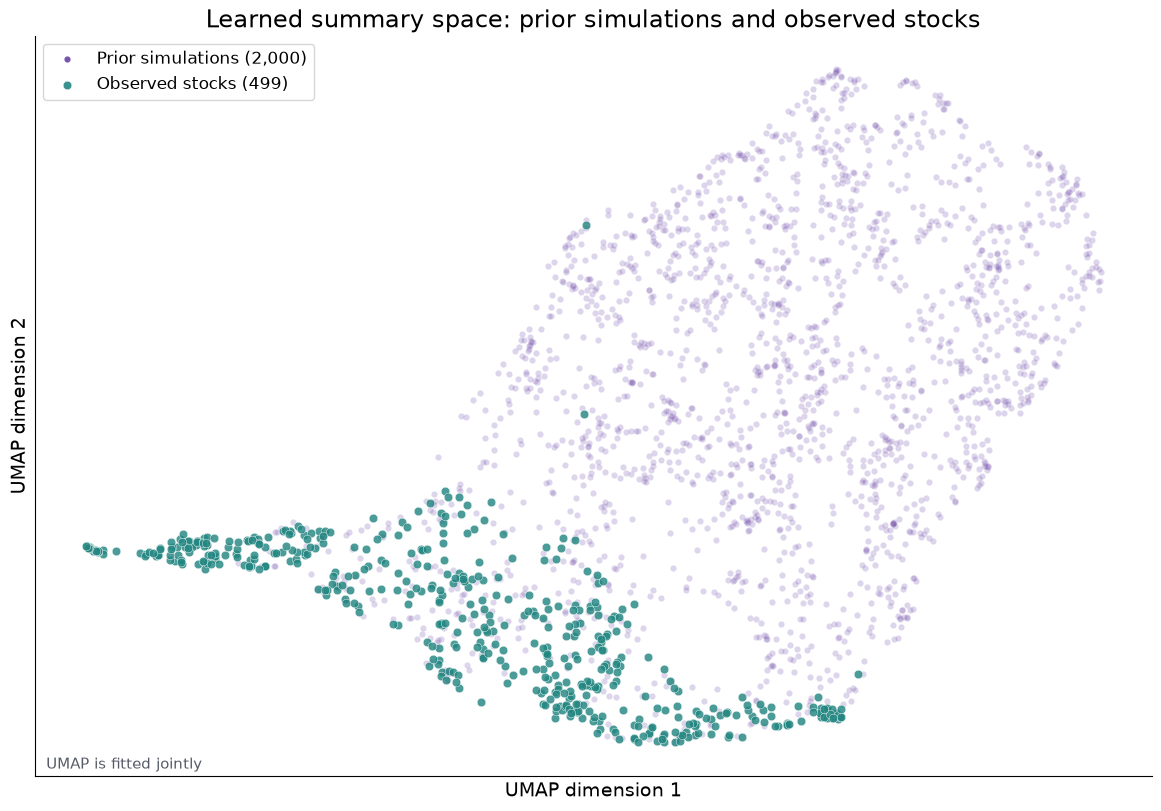

In [ ]:
simulated_summaries = screener.prior_summary_embeddings(
    approximator, n_simulations=2_000, batch_size=64, seed=44
)

viz.embedding_space_plot(
    simulated_summaries,
    real_summaries,
    labels=("Prior simulations", "Observed stocks"),
    path=FIGURES / "02_summary_embedding_umap.png",
    seed=44,
)

## 4. Rank gain probability against tail loss

Let $\mathcal D_T=(r_{T-255},\ldots,r_T)$ be a stock's observed window, $R_{T,20}=\prod_{h=1}^{20}(1+\widetilde r_{T+h})-1$ a fresh simulated 20-day compounded return, and $c=0.20\%$ the round-trip cost.

- **Gain probability:** $p_{\mathrm{gain}}=P(R_{T,20}>c\mid\mathcal D_T)$.
- **Expected shortfall:** $ES_{95}$ is the average loss among the worst 5% of simulated outcomes.
- **Score:** $(100 p_{\mathrm{gain}}) / ES_{95}(\%)$; for example, $70/10=7$.

Fresh cascade phases are simulated conditional on the inferred parameters, but not on a latent end-of-window volatility state. This is a stationary model-based scenario ranking, not a state-conditioned forecast.

In [10]:
risk_start = perf_counter()
ranking, coverage_checks = screener.screen_stocks(
    posterior, 
    series, 
    metadata, 
    rule=RULE,
    n_parameter_draws=64, 
    n_replications=512, 
    n_ppc=512, 
    seed=43,
)

risk_seconds = perf_counter() - risk_start
ranking.to_csv(FIGURES / "stock_screen.csv", index=False)
coverage_checks.to_csv(FIGURES / "coverage_checks.csv", index=False)

pd.DataFrame({
    "stage": ["Posterior inference", "Risk simulation + predictive checks"],
    "seconds": [inference_seconds, risk_seconds],
    "stocks": [len(series), len(series)],
}).to_csv(FIGURES / "deployment_timing.csv", index=False)
print(f"Ranked {len(ranking)} stocks in {risk_seconds:.1f}s.")

Risk + PPC: 25/499 stocks (7.3s)
Risk + PPC: 50/499 stocks (14.6s)
Risk + PPC: 75/499 stocks (21.9s)
Risk + PPC: 100/499 stocks (29.2s)
Risk + PPC: 125/499 stocks (36.6s)
Risk + PPC: 150/499 stocks (43.9s)
Risk + PPC: 175/499 stocks (51.1s)
Risk + PPC: 200/499 stocks (58.4s)
Risk + PPC: 225/499 stocks (65.6s)
Risk + PPC: 250/499 stocks (73.0s)
Risk + PPC: 275/499 stocks (80.2s)
Risk + PPC: 300/499 stocks (87.5s)
Risk + PPC: 325/499 stocks (94.8s)
Risk + PPC: 350/499 stocks (102.0s)
Risk + PPC: 375/499 stocks (109.3s)
Risk + PPC: 400/499 stocks (116.6s)
Risk + PPC: 425/499 stocks (123.8s)
Risk + PPC: 450/499 stocks (131.1s)
Risk + PPC: 475/499 stocks (138.5s)
Risk + PPC: 499/499 stocks (145.6s)
Ranked 499 stocks in 145.7s.


### Ranking uncertainty and fit warnings

- **Left:** posterior-predictive gain probability against 20-day expected shortfall.
- **Right:** the twelve highest scores; lines show central 90% intervals across posterior parameter draws.

Color indicates heuristic fit warnings. Each observed mean, volatility, tail quantiles, and maximum drawdown is compared with separate 99% prior- and posterior-predictive ranges; a $\bar\sigma$ posterior concentrated near its training bounds is also flagged. These are marginal diagnostics rather than a joint coverage test, and no stock is removed from the ranking.

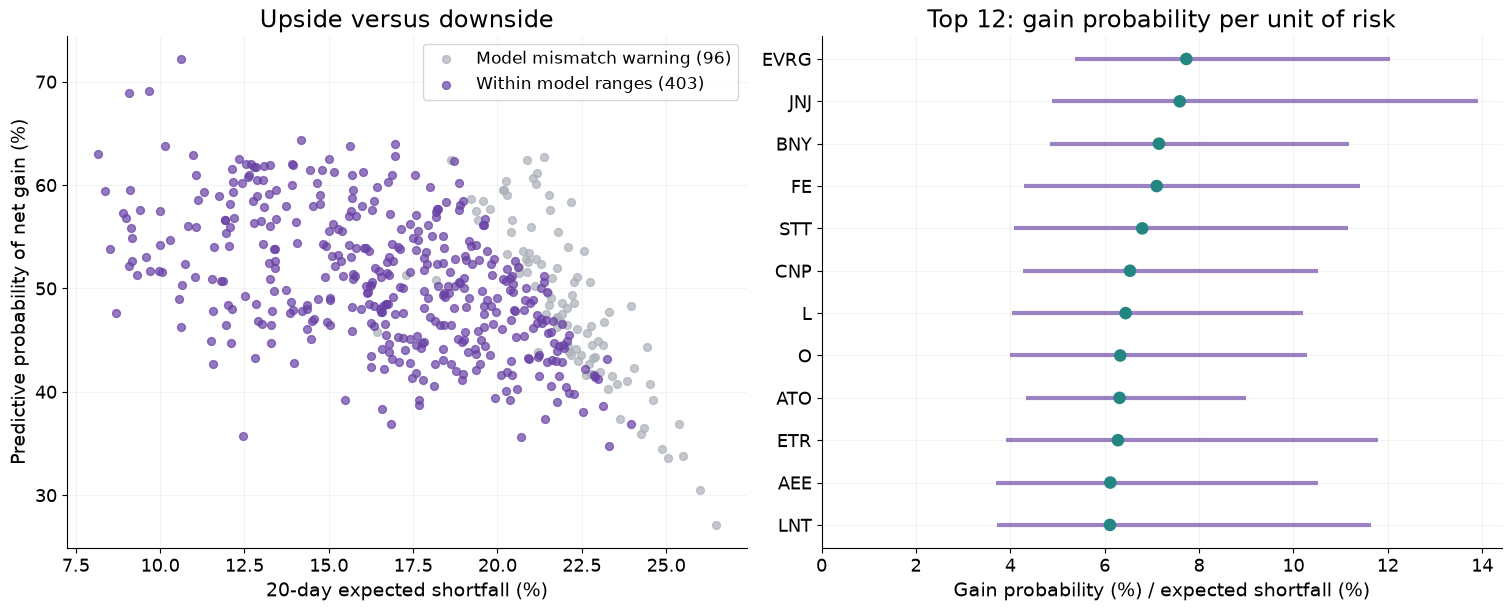

In [11]:
viz.opportunity_plot(ranking, FIGURES / "02_opportunities.png")

### Top five stocks

The table is sorted by gain/ES. Gain probability includes trading costs. `coverage_ok` is the implementation's legacy name for "all displayed fit diagnostics passed"; it is not a statistical coverage guarantee.

In [12]:
columns = [
    "rank", "ticker", "sector", "gain_to_es", "predictive_gain_probability",
    "predictive_es95_pct", "es95_posterior_q05_pct", "es95_posterior_q95_pct",
    "coverage_ok",
]

display(ranking[columns].head(5).style.format({"predictive_gain_probability": "{:.1%}"}, precision=2))

,rank,ticker,sector,gain_to_es,predictive_gain_probability,predictive_es95_pct,es95_posterior_q05_pct,es95_posterior_q95_pct,coverage_ok
0,1,EVRG,Utilities,7.73,63.0%,8.15,6.00,9.58,True
1,2,JNJ,Health Care,7.59,68.9%,9.08,5.76,11.22,True
2,3,BNY,Financials,7.15,69.1%,9.66,7.09,11.96,True
3,4,FE,Utilities,7.10,59.5%,8.37,6.41,10.52,True
4,5,STT,Financials,6.80,72.2%,10.62,7.19,13.11,True


### Recovered univariate parameters

For the twelve leaders, dots show posterior medians and lines show central 90% intervals for the same $\mu$, $\bar\sigma$, $q$, and $\nu$ introduced in the univariate notebook. Drift and scale are expressed in percent.

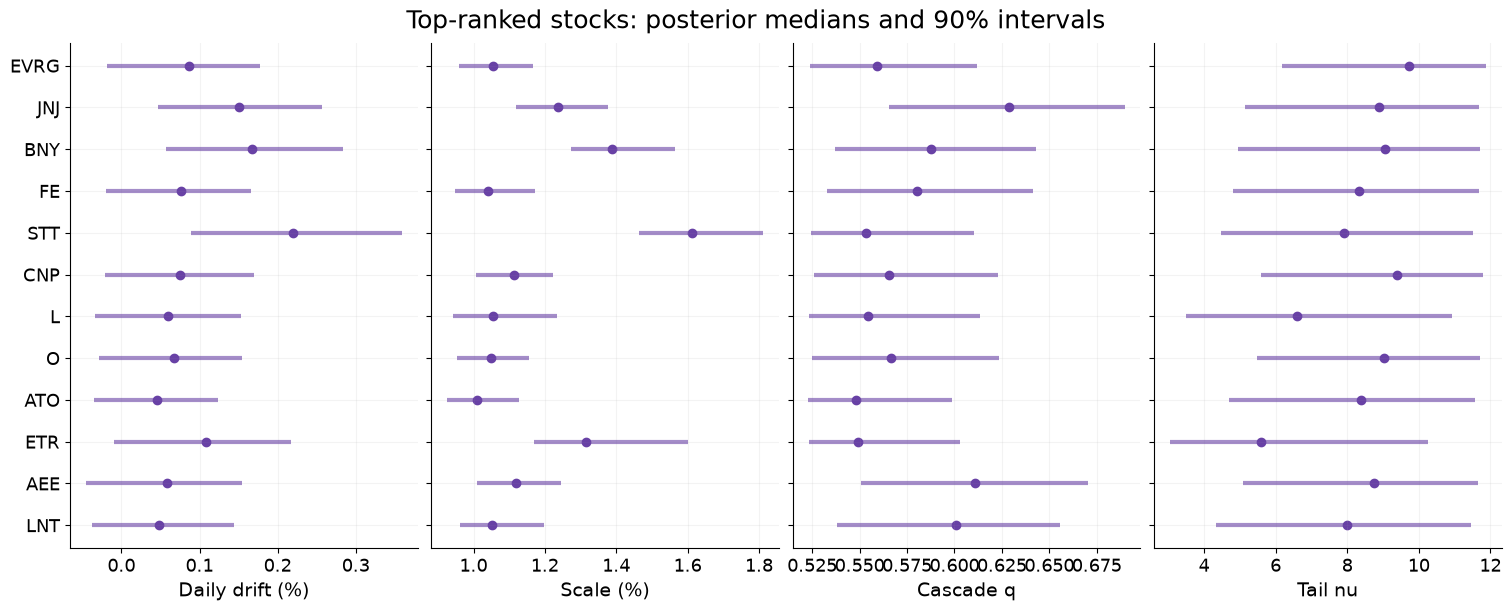

In [13]:
viz.parameter_plot(ranking, FIGURES / "03_parameter_posteriors.png")

## 5. Posterior retrodictive checks for the four leaders

For each leader, every posterior draw generates one fresh 256-day path under the fitted model. These panels ask whether the model can reproduce the observed window; they are not dated forecasts.

- **Wealth:** observed growth in black dashes, the predictive median in purple, and pointwise 68% and 92% intervals.
- **Daily returns:** observed and pooled predictive histograms, with the predictive median marked.
- **Maximum drawdown:** one value per resimulated path; vertical lines mark the observed and predictive medians.

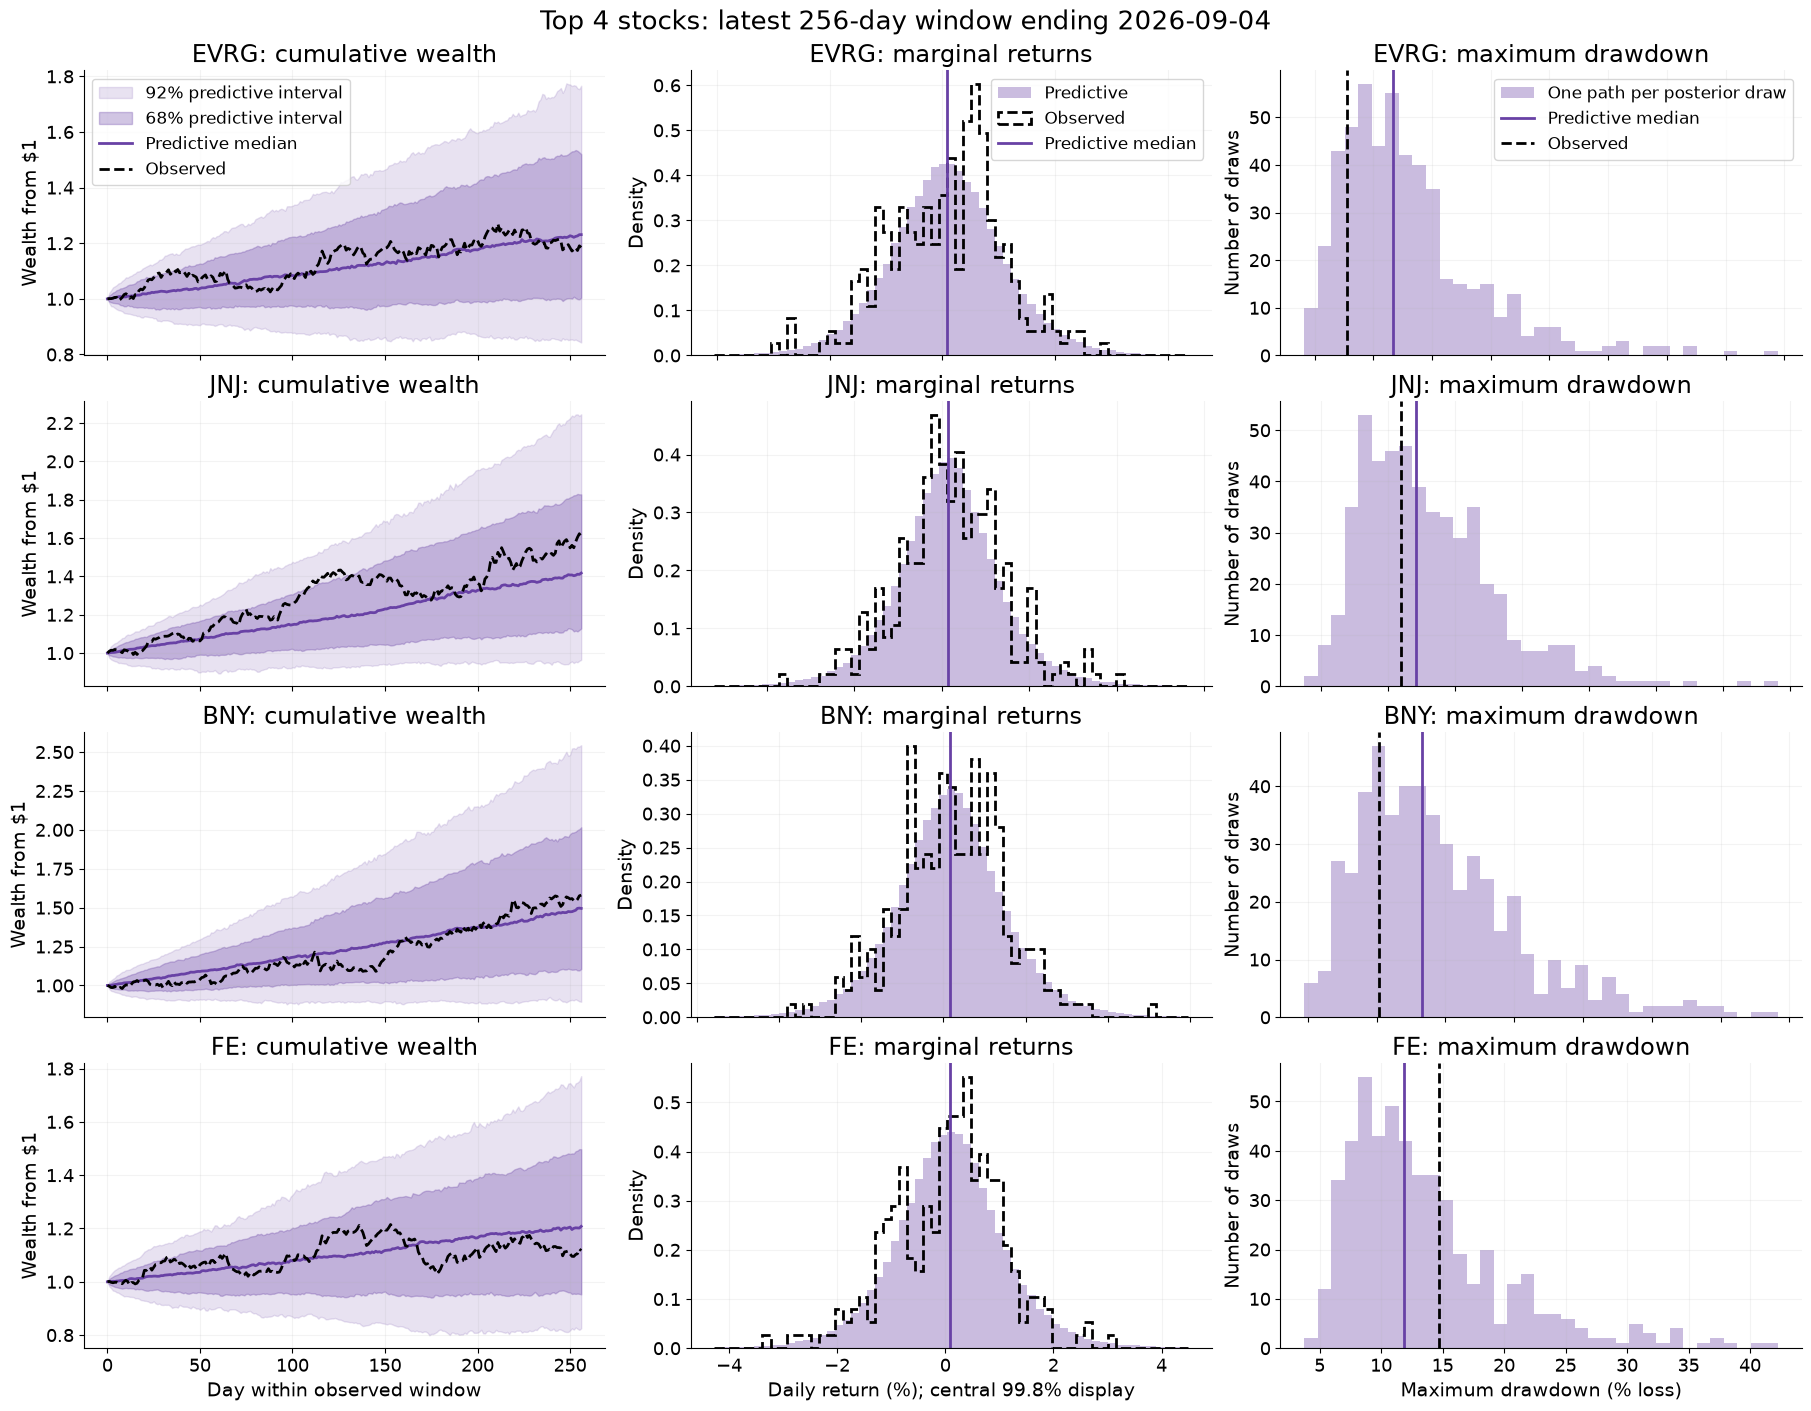

In [ ]:
viz.fit_plot(
    posterior, series, metadata, ranking, dates,
    FIGURES / "04_leading_stock_fit.png", top_n=4, seed=45, figsize=(18, 14)
)

## 6. What we achieved and next steps

Amortization turns one trained estimator into hundreds of fast, comparable marginal fits. The ranking is useful for screening individual return distributions, but independently simulated stocks cannot produce coherent portfolio scenarios because they contain no joint shock structure. The [next notebook](./mmar_multivariate.ipynb) keeps the same drift, scale, cascade, and Student-$t$ ingredients while replacing scalar innovations with one correlated multivariate innovation vector.